# 1. Статистика по датасетам

In [2]:
# загрузки
!pip install kaggle --quiet
!pip install contractions --quiet
!pip install gdown --quiet
!pip install wordsegment --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.6 MB/s eta 0:00:00


In [62]:
import pandas as pd
import numpy as np
from google.colab import files
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

```text
Dataset Description
In the challenge, you are predicting item sales at stores in various locations for two 28-day time periods.
Information about the data is found in the M5 Participants Guide.

Files
calendar.csv - Contains information about the dates on which the products are sold.
sales_train_validation.csv - Contains the historical daily unit sales data per product and store [d_1 - d_1913]
sample_submission.csv - The correct format for submissions. Reference the Evaluation tab for more info.
sell_prices.csv - Contains information about the price of the products sold per store and date.
sales_train_evaluation.csv - Includes sales [d_1 - d_1941] (labels used for the Public leaderboard)

In [4]:
calendar = pd.read_csv('/content/calendar.csv')
sales_train_evaluation = pd.read_csv('/content/sales_train_evaluation.csv')
sales_train_validation = pd.read_csv('/content/sales_train_validation.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')
sell_prices = pd.read_csv('/content/sell_prices.csv')

In [5]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [6]:
print(f'Первый день: {calendar['date'].values[0]}')
print(f'Последний день: {calendar['date'].values[-1]}')
print(f'Количество дней: {len(calendar)}')

Первый день: 2011-01-29
Последний день: 2016-06-19
Количество дней: 1969


Интересно посмотреть, что за мероприятия и праздники указаны в датасете

In [7]:
len(calendar['event_name_1'].value_counts())

30

In [8]:
calendar['event_type_1'].value_counts()

,count
event_type_1,
Religious,55
National,52
Cultural,37
Sporting,18


In [9]:
calendar['event_name_2'].value_counts()

,count
event_name_2,
Father's day,2
Easter,1
Cinco De Mayo,1
OrthodoxEaster,1


In [10]:
calendar['event_type_2'].value_counts()

,count
event_type_2,
Cultural,4
Religious,1


In [11]:
calendar[calendar['event_name_1'].notna()].sample(5)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
435,2012-04-08,11211,Sunday,2,4,2012,d_436,Easter,Cultural,NaN,NaN,1,0,1
1780,2015-12-14,11546,Monday,3,12,2015,d_1781,Chanukah End,Religious,NaN,NaN,0,0,1
1601,2015-06-18,11520,Thursday,6,6,2015,d_1602,Ramadan starts,Religious,NaN,NaN,0,0,0
1112,2014-02-14,11402,Friday,7,2,2014,d_1113,ValentinesDay,Cultural,NaN,NaN,0,0,1
99,2011-05-08,11115,Sunday,2,5,2011,d_100,Mother's day,Cultural,NaN,NaN,1,0,1


In [12]:
calendar[calendar['event_name_2'].notna()].sample(5)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
1968,2016-06-19,11621,Sunday,2,6,2016,d_1969,NBAFinalsEnd,Sporting,Father's day,Cultural,0,0,0
85,2011-04-24,11113,Sunday,2,4,2011,d_86,OrthodoxEaster,Religious,Easter,Cultural,0,0,0
1177,2014-04-20,11412,Sunday,2,4,2014,d_1178,Easter,Cultural,OrthodoxEaster,Religious,0,0,0
1233,2014-06-15,11420,Sunday,2,6,2014,d_1234,NBAFinalsEnd,Sporting,Father's day,Cultural,0,1,1
827,2013-05-05,11315,Sunday,2,5,2013,d_828,OrthodoxEaster,Religious,Cinco De Mayo,Cultural,1,1,1


In [13]:
len(calendar[calendar['event_name_2'].notna()])

5

Небольшое наблюдение - event_name_2 появляется только тогда, когда у нас пересекаются два мероприятия в один день

In [14]:
print(f'Количество дней snap_CA: {calendar['snap_CA'].sum()}')
print(f'Количество дней snap_TX: {calendar['snap_TX'].sum()}')
print(f'Количество дней snap_WI: {calendar['snap_WI'].sum()}')
print(f'\nКоличество дней, когда совпадают CA и TX: {
    ((calendar['snap_CA'] == 1) & (calendar['snap_TX'] == 1)).sum()
    }')
print(f'Количество дней, когда совпадают CA и WI: {
    ((calendar['snap_CA'] == 1) & (calendar['snap_WI'] == 1)).sum()
    }')
print(f'Количество дней, когда совпадают TX и WI: {
    ((calendar['snap_TX'] == 1) & (calendar['snap_WI'] == 1)).sum()
    }')
print(f'Количество дней, когда совпадают CA, TX и WI: {
    ((calendar['snap_CA'] == 1) & (calendar['snap_TX'] == 1) & (calendar['snap_WI'] == 1)).sum()
    }')

Количество дней snap_CA: 650
Количество дней snap_TX: 650
Количество дней snap_WI: 650

Количество дней, когда совпадают CA и TX: 390
Количество дней, когда совпадают CA и WI: 390
Количество дней, когда совпадают TX и WI: 455
Количество дней, когда совпадают CA, TX и WI: 260


In [15]:
sales_train_evaluation.shape

(30490, 1947)

In [16]:
sales_train_evaluation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [17]:
sales_train_validation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [18]:
sales_train_evaluation['store_id'].value_counts()

,count
store_id,
CA_1,3049
CA_2,3049
CA_3,3049
CA_4,3049
TX_1,3049
TX_2,3049
TX_3,3049
WI_1,3049
WI_2,3049


In [19]:
sales_train_evaluation['item_id'].value_counts()

,count
item_id,
FOODS_3_827,10
HOBBIES_1_001,10
HOBBIES_1_002,10
HOBBIES_1_003,10
HOBBIES_1_004,10
...,...
HOBBIES_1_014,10
HOBBIES_1_013,10
HOBBIES_1_012,10


In [20]:
sales_train_evaluation['dept_id'].value_counts()

,count
dept_id,
FOODS_3,8230
HOUSEHOLD_1,5320
HOUSEHOLD_2,5150
HOBBIES_1,4160
FOODS_2,3980
FOODS_1,2160
HOBBIES_2,1490


In [21]:
sales_train_evaluation['cat_id'].value_counts()

,count
cat_id,
FOODS,14370
HOUSEHOLD,10470
HOBBIES,5650


In [22]:
print(f"Всего SKU: {sales_train_evaluation['item_id'].nunique()}")
print(f"Магазинов: {sales_train_evaluation['store_id'].nunique()}")

days = [col for col in sales_train_evaluation.columns if col.startswith('d_')]
print(f"Дней в истории: {len(days)}")

values = sales_train_evaluation[days].values.flatten()
print(f"Доля нулевых продаж: {(values == 0).mean():.2%}")
print(f"Средние ненулевые продажи: {values[values > 0].mean():.2f}")

days_with_sales = (sales_train_evaluation[days].values > 0).sum(axis=1)
print(f"SKU с <50 днями продаж: {(days_with_sales < 50).sum()} ({(days_with_sales < 50).mean():.1%})")
print(f"SKU с <200 днями продаж: {(days_with_sales < 200).sum()} ({(days_with_sales < 200).mean():.1%})")


Всего SKU: 3049
Магазинов: 10
Дней в истории: 1941
Доля нулевых продаж: 68.00%
Средние ненулевые продажи: 3.53
SKU с <50 днями продаж: 282 (0.9%)
SKU с <200 днями продаж: 5337 (17.5%)


In [23]:
max_sales_per_sku = sales_train_evaluation[days].max(axis=1)
max_sales_df = pd.DataFrame({
    'item_id': sales_train_evaluation['item_id'],
    'store_id': sales_train_evaluation['store_id'],
    'max_daily_sales': max_sales_per_sku
}).sort_values('max_daily_sales', ascending=False)
max_sales_df.head()

,item_id,store_id,max_daily_sales
8412,FOODS_3_090,CA_3,763
3006,FOODS_3_785,CA_1,648
14307,FOODS_2_285,TX_1,634
16274,HOUSEHOLD_1_474,TX_2,626
13354,HOUSEHOLD_2_062,TX_1,601


In [24]:
sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [25]:
print(f"Диапазон цен: ${sell_prices['sell_price'].min():.2f} – ${sell_prices['sell_price'].max():.2f}")
print(f'Количество уникальных цен: {sell_prices['sell_price'].nunique()}')
print(f'Медиана цен: {sell_prices['sell_price'].median()}')
print(f'Арифметическое среднее: {sell_prices['sell_price'].mean():.5f}')
print(f'Мода:')
sell_prices['sell_price'].mode()

Диапазон цен: $0.01 – $107.32
Количество уникальных цен: 1048
Медиана цен: 3.47
Арифметическое среднее: 4.41095
Мода:


,sell_price
0,2.98


In [26]:
# Волатильность цен: меняются ли цены со временем?
price_changes = sell_prices.groupby(['store_id', 'item_id'])['sell_price'].nunique()
print(f"Товаров с >1 ценой: {(price_changes > 1).sum()} ({(price_changes > 1).mean():.1%})")

Товаров с >1 ценой: 22243 (73.0%)


In [27]:
sample_submission.head()

,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_validation,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
sample_submission.shape

(60980, 29)

# 2. Выделение сабсета

In [29]:
subset_sales = sales_train_evaluation[(sales_train_evaluation['store_id'] == 'CA_1') &
                       ((sales_train_evaluation['dept_id'] == 'FOODS_1') |
                       (sales_train_evaluation['dept_id'] == 'FOODS_2'))]

In [30]:
days_cols = [col for col in sales_train_evaluation.columns if col.startswith('d_')]
subset_long = subset_sales.melt(
    id_vars=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=days_cols,
    var_name='d',
    value_name='sales'
)

In [31]:
calendar_subset = calendar[
    calendar['d'].isin(subset_long['d'].unique())
][[
    'd', 'wday', 'month', 'year',
    'event_name_1', 'event_type_1',
    'event_name_2', 'event_type_2',
    'snap_CA', 'wm_yr_wk'
]].copy()
calendar_subset.head()

,d,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,wm_yr_wk
0,d_1,1,1,2011,NaN,NaN,NaN,NaN,0,11101
1,d_2,2,1,2011,NaN,NaN,NaN,NaN,0,11101
2,d_3,3,1,2011,NaN,NaN,NaN,NaN,0,11101
3,d_4,4,2,2011,NaN,NaN,NaN,NaN,1,11101
4,d_5,5,2,2011,NaN,NaN,NaN,NaN,1,11101


In [32]:
# Делаем merge sales и calendar (по ключу 'd')
df_merged = subset_long.merge(calendar_subset, on='d', how='left')

# Подготовка и merge с ценами
prices_subset = sell_prices[
    (sell_prices['store_id'] == 'CA_1') &
    (sell_prices['item_id'].isin(subset_sales['item_id']))
][['store_id', 'item_id', 'wm_yr_wk', 'sell_price']].copy()
df_final = df_merged.merge(prices_subset, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

In [33]:
# проверим итоговый результат
print(f"Итоговый размер датасета: {df_final.shape}")
print(f"Пропуски в sales: {df_final['sales'].isna().sum()}")
print(f"Пропуски в sell_price: {df_final['sell_price'].isna().sum()}")
df_final.head()

Итоговый размер датасета: (1191774, 17)
Пропуски в sales: 0
Пропуски в sell_price: 211715


,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,wm_yr_wk,sell_price
0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.00
1,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,7.88
2,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.88
3,FOODS_1_004,FOODS_1,FOODS,CA_1,CA,d_1,0,1,1,2011,NaN,NaN,NaN,NaN,0,11101,NaN
4,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,d_1,3,1,1,2011,NaN,NaN,NaN,NaN,0,11101,2.94


In [34]:
# более детально посмотрим на пропуски - сколько недель без цен для каждого товара?
price_coverage = df_final.groupby('item_id')['sell_price'].apply(
    lambda x: 1 - x.isna().mean()
)
print(f"Среднее покрытие цен по товарам: {price_coverage.mean():.1%}")
print(f"Товаров с покрытием <90%: {(price_coverage < 0.9).sum()}")

# пропуски по периодам
missing_by_period = df_final[df_final['sell_price'].isna()].groupby(
    df_final['d'].str.extract(r'd_(\d+)')[0].astype(int) // 200  # группировка будет по 200 дней
).size()
print(f'Распределение пропусков по периодам: \n{missing_by_period}')

# доля пропусков по подкатегориям
missing_by_dept = df_final.groupby('dept_id')['sell_price'].apply(
    lambda x: x.isna().mean()
)
print(f'Доля пропусков по подкатегориям: \n{missing_by_dept}')

Среднее покрытие цен по товарам: 82.2%
Товаров с покрытием <90%: 253
Распределение пропусков по периодам: 
0
0    55616
1    47865
2    36203
3    29240
4    20334
5    15088
6     5556
7     1181
8      632
dtype: int64
Доля пропусков по подкатегориям: 
dept_id
FOODS_1    0.146192
FOODS_2    0.194718
Name: sell_price, dtype: float64


## 3. Визуальный EDA - оценить zero-inflation, выбросы, необходимость трансформаций.

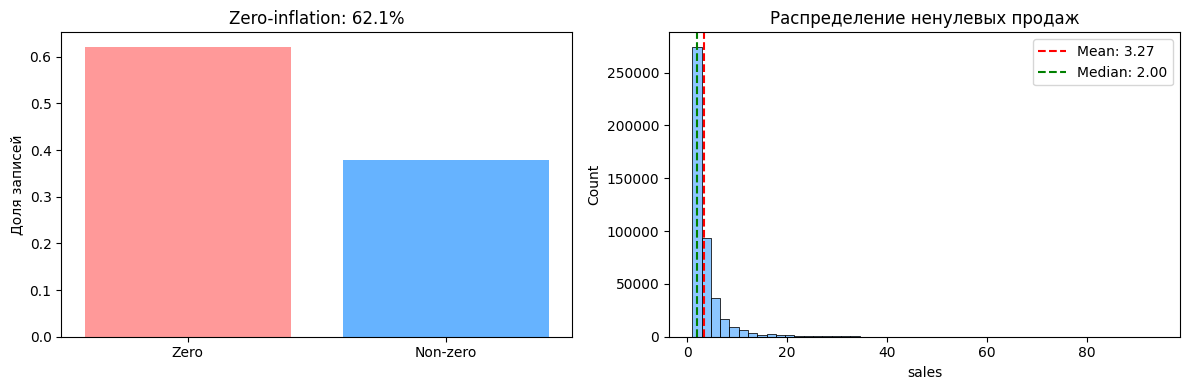

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# оценка доли нулей
zero_rate = (df_final['sales'] == 0).mean()
ax[0].bar(['Zero', 'Non-zero'], [zero_rate, 1-zero_rate], color=['#ff9999','#66b3ff'])
ax[0].set_title(f'Zero-inflation: {zero_rate:.1%}')
ax[0].set_ylabel('Доля записей')

# распределение ненулевых продаж
nonzero = df_final.loc[df_final['sales'] > 0, 'sales']
sns.histplot(nonzero, bins=50, ax=ax[1], color='#66b3ff', edgecolor='black')
ax[1].axvline(nonzero.mean(), color='red', linestyle='--', label=f'Mean: {nonzero.mean():.2f}')
ax[1].axvline(nonzero.median(), color='green', linestyle='--', label=f'Median: {nonzero.median():.2f}')
ax[1].set_title('Распределение ненулевых продаж')
ax[1].legend()

plt.tight_layout()
plt.show()

In [36]:
print(f'Максимальные продажи: {df_final['sales'].max()}')

Максимальные продажи: 94


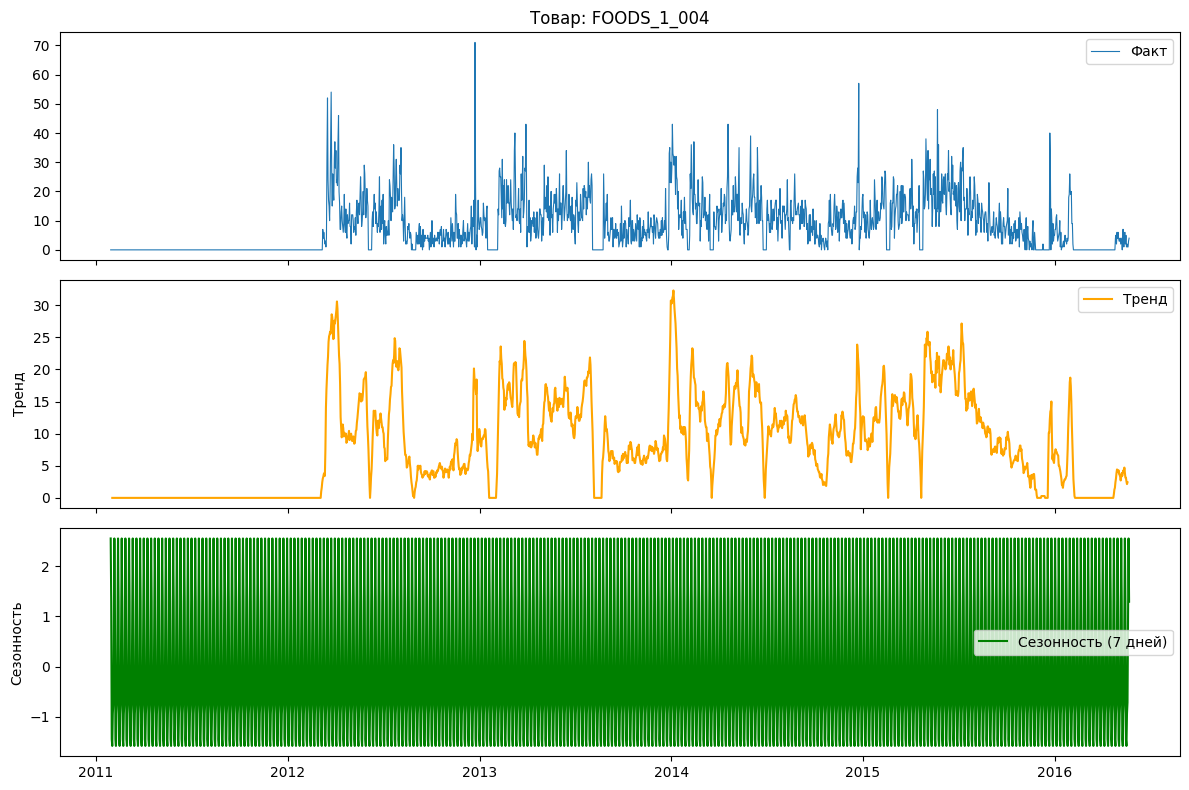

In [37]:
# сумма продаж по каждому item_id
item_sales = df_final.groupby('item_id')['sales'].sum()
threshold = item_sales.quantile(0.75)
sample_item = item_sales[item_sales > threshold].index[0]

# формирование временного ряда
ts_df = df_final[df_final['item_id'] == sample_item].copy()
ts_df['date'] = pd.to_datetime(
    ts_df['d'].str.replace('d_', '').astype(int) - 1,
    unit='D', origin='2011-01-29'
)
ts = ts_df.set_index('date')['sales'].asfreq('D')  # гарантируем ежедневную частоту

# декомпозиция
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
decomp = seasonal_decompose(ts, model='additive', period=7)

ax[0].plot(ts, label='Факт', linewidth=0.8)
ax[0].set_title(f'Товар: {sample_item}')
ax[0].legend()

ax[1].plot(decomp.trend, label='Тренд', color='orange')
ax[1].set_ylabel('Тренд'); ax[1].legend()

ax[2].plot(decomp.seasonal, label='Сезонность (7 дней)', color='green')
ax[2].set_ylabel('Сезонность'); ax[2].legend()
plt.tight_layout()
plt.show()

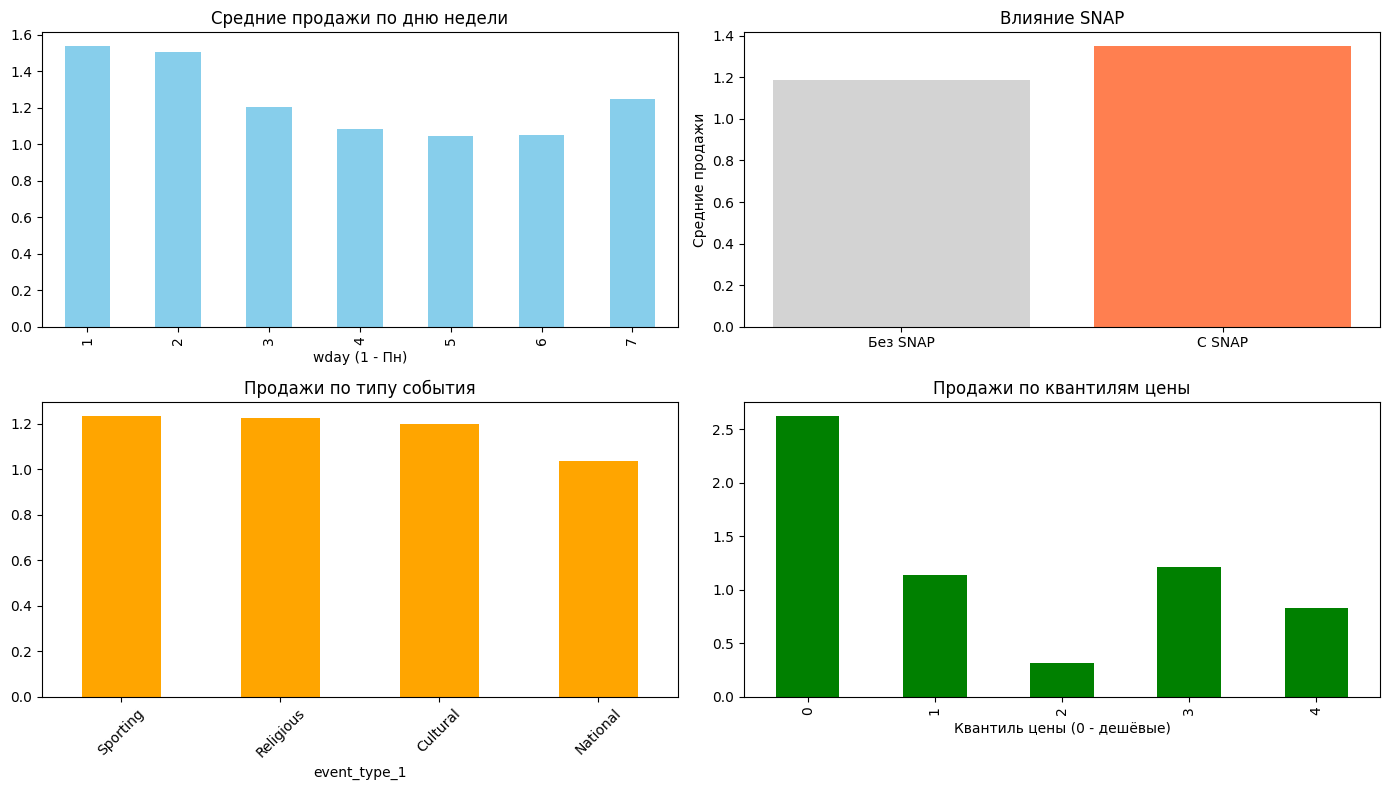

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# средние продажи по дню недели
df_final.groupby('wday')['sales'].mean().reindex(range(1,8)).plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Средние продажи по дню недели'); axes[0,0].set_xlabel('wday (1 - Пн)')

# влияние snap на продажи
snap = df_final.groupby('snap_CA')['sales'].mean()
axes[0,1].bar(['Без SNAP', 'С SNAP'], [snap[0], snap[1]], color=['lightgray','coral'])
axes[0,1].set_title('Влияние SNAP'); axes[0,1].set_ylabel('Средние продажи')

# продажи по типу события
evt = df_final.groupby('event_type_1')['sales'].mean().dropna().sort_values(ascending=False)
evt.plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Продажи по типу события'); axes[1,0].tick_params(axis='x', rotation=45)

# продажи в зависимости от цены товара
df_final['price_bin'] = pd.qcut(df_final['sell_price'].fillna(df_final['sell_price'].median()), q=5, labels=False)
df_final.groupby('price_bin')['sales'].mean().plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Продажи по квантилям цены'); axes[1,1].set_xlabel('Квантиль цены (0 - дешёвые)')

plt.tight_layout()
plt.show()

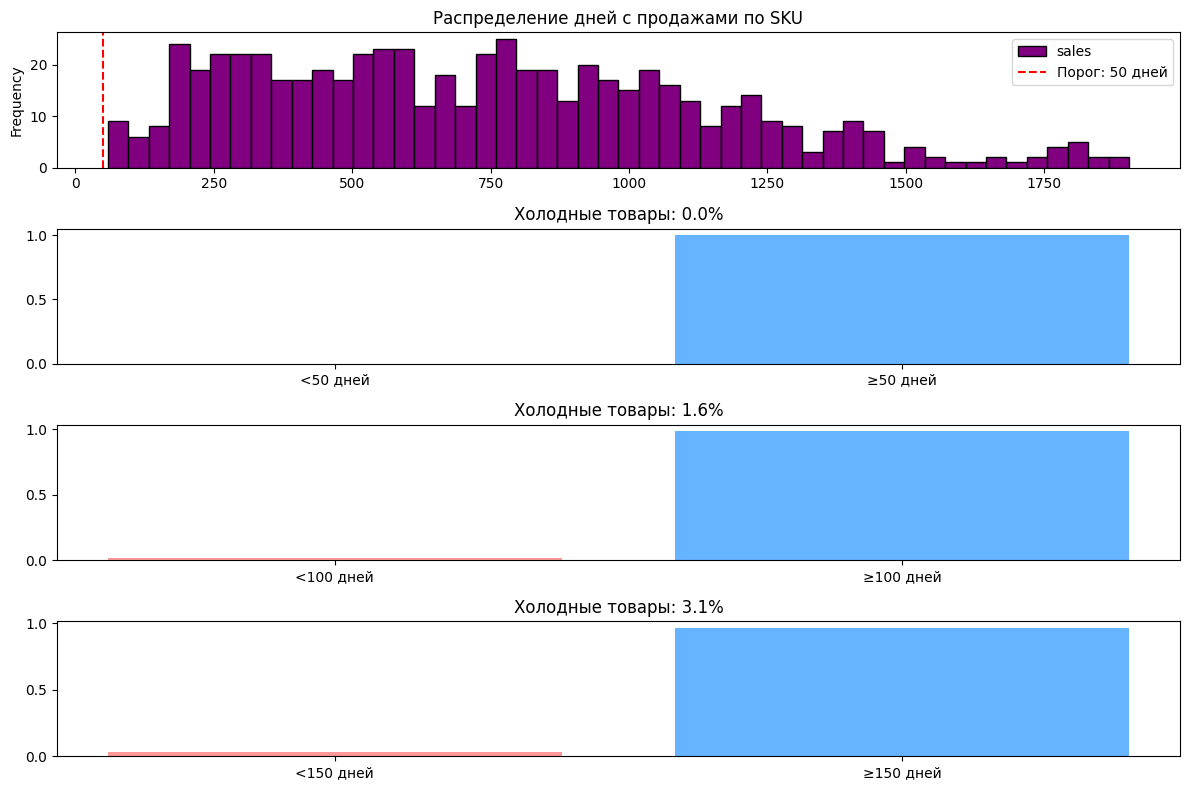

In [42]:
# сколько дней с продажами > 0 у каждого товара
sales_days = df_final.groupby('item_id')['sales'].apply(lambda x: (x > 0).sum())

fig, ax = plt.subplots(4, 1, figsize=(12, 8))
sales_days.plot(kind='hist', bins=50, ax=ax[0], color='purple', edgecolor='black')
ax[0].axvline(50, color='red', linestyle='--', label='Порог: 50 дней')
ax[0].set_title('Распределение дней с продажами по SKU')
ax[0].legend()

# доля холодных товаров
cold_ratio = (sales_days < 50).mean()
ax[1].bar(['<50 дней', '≥50 дней'], [cold_ratio, 1-cold_ratio], color=['#ff9999','#66b3ff'])
ax[1].set_title(f'Холодные товары: {cold_ratio:.1%}')

cold_ratio = (sales_days < 100).mean()
ax[2].bar(['<100 дней', '≥100 дней'], [cold_ratio, 1-cold_ratio], color=['#ff9999','#66b3ff'])
ax[2].set_title(f'Холодные товары: {cold_ratio:.1%}')

cold_ratio = (sales_days < 150).mean()
ax[3].bar(['<150 дней', '≥150 дней'], [cold_ratio, 1-cold_ratio], color=['#ff9999','#66b3ff'])
ax[3].set_title(f'Холодные товары: {cold_ratio:.1%}')

plt.tight_layout()
plt.show()

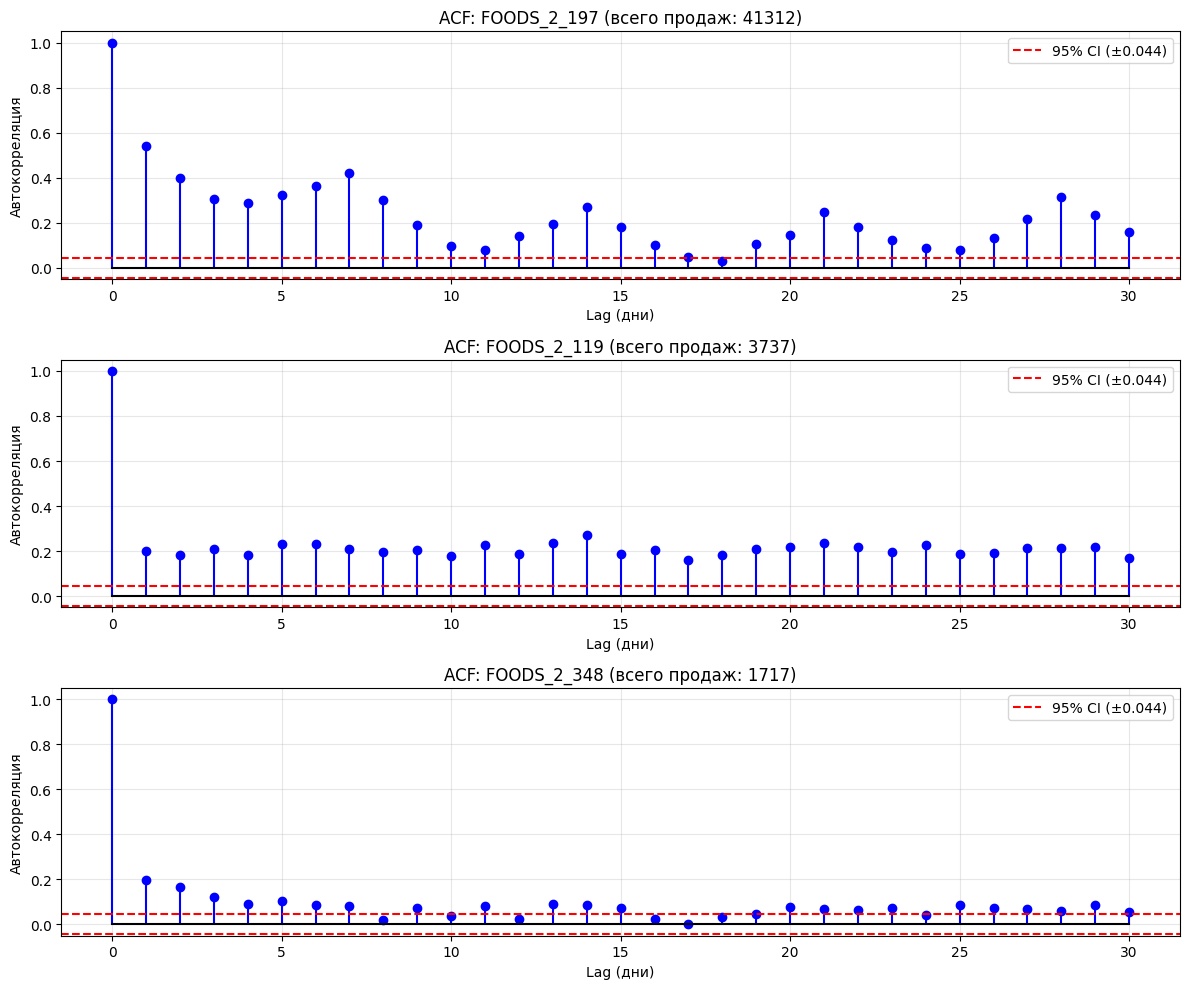


Значимые лаги (за пределами 95% доверительного интервала)
FOODS_2_197:
Все значимые лаги (первые 10): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Недельные лаги (7, 14, 21, 28): [7, 14, 21, 28]
FOODS_2_119:
Все значимые лаги (первые 10): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Недельные лаги (7, 14, 21, 28): [7, 14, 21, 28]
FOODS_2_348:
Все значимые лаги (первые 10): [1, 2, 3, 4, 5, 6, 7, 9, 11, 13]
Недельные лаги (7, 14, 21, 28): [7, 14, 21, 28]


In [65]:
item_sales = df_final.groupby('item_id')['sales'].sum()

item_high = item_sales.nlargest(1).index[0] # товар с высоким спросом (топ-1)
item_med = item_sales[item_sales >= item_sales.quantile(0.5)].sample(1, random_state=42).index[0] # товар со средним спросом (медиана)
item_low = item_sales[(item_sales >= item_sales.quantile(0.2)) &
                      (item_sales > 50)].sample(1, random_state=42).index[0] # товар с низким, но стабильным спросом (20-й перцентиль, >50 продаж всего)

items_to_plot = [item_high, item_med, item_low]

# графики ACF
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, item in enumerate(items_to_plot):
    ts = df_final[df_final['item_id'] == item]['sales'].dropna()

    acf_vals = acf(ts, nlags=30, fft=False) # считается ACF (30 лагов)
    ci = 1.96 / np.sqrt(len(ts))  # 95% доверительный интервал

    axes[i].stem(range(len(acf_vals)), acf_vals, linefmt='b-', markerfmt='bo', basefmt='k-') # график stem plot
    axes[i].axhline(ci, color='r', linestyle='--', label=f'95% CI (±{ci:.3f})')
    axes[i].axhline(-ci, color='r', linestyle='--')
    axes[i].set_title(f'ACF: {item} (всего продаж: {item_sales[item]:.0f})')
    axes[i].set_xlabel('Lag (дни)')
    axes[i].set_ylabel('Автокорреляция')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# вывод значимых лагов
print("\nЗначимые лаги (за пределами 95% доверительного интервала)")
for item in items_to_plot:
    ts = df_final[df_final['item_id'] == item]['sales'].dropna()
    acf_vals = acf(ts, nlags=30, fft=False)
    ci = 1.96 / np.sqrt(len(ts))
    sig_lags = [lag for lag, val in enumerate(acf_vals) if abs(val) > ci and lag > 0]
    weekly_lags = [l for l in sig_lags if l in [7, 14, 21, 28]]
    print(f"{item}:")
    print(f"Все значимые лаги (первые 10): {sig_lags[:10]}")
    print(f"Недельные лаги (7, 14, 21, 28): {weekly_lags if weekly_lags else 'не обнаружены'}")

In [49]:
# корреляция с календарными событиями
event_cols = ['event_name_1', 'event_type_1']
for col in event_cols:
    if col in df_final.columns:
        event_effect = df_final.groupby(col)['sales'].mean()
        print(f"\n{col}:")
        print(event_effect.sort_values(ascending=False).head())


event_name_1:
event_name_1
LaborDay          1.479479
OrthodoxEaster    1.476547
SuperBowl         1.394408
VeteransDay       1.325407
ColumbusDay       1.315635
Name: sales, dtype: float64

event_type_1:
event_type_1
Sporting     1.231270
Religious    1.226143
Cultural     1.198565
National     1.035863
Name: sales, dtype: float64


In [56]:
# поиск резких изменений по подкатегориям
category_sales = df_final.groupby(['d', 'dept_id'])['sales'].sum().unstack()
for dept in ['FOODS_1', 'FOODS_2']:
    dept_ts = category_sales[dept]
    rolling_mean = dept_ts.rolling(window=30).mean() # сглаживание шума, оставляем тренд
    jumps = rolling_mean.diff().abs() > rolling_mean.std() * 2 # если изменение > 2 стандартных отклонений - аномалия
    print(f"{dept}: найдено {jumps.sum()} структурных изменений")

FOODS_1: найдено 0 структурных изменений
FOODS_2: найдено 0 структурных изменений


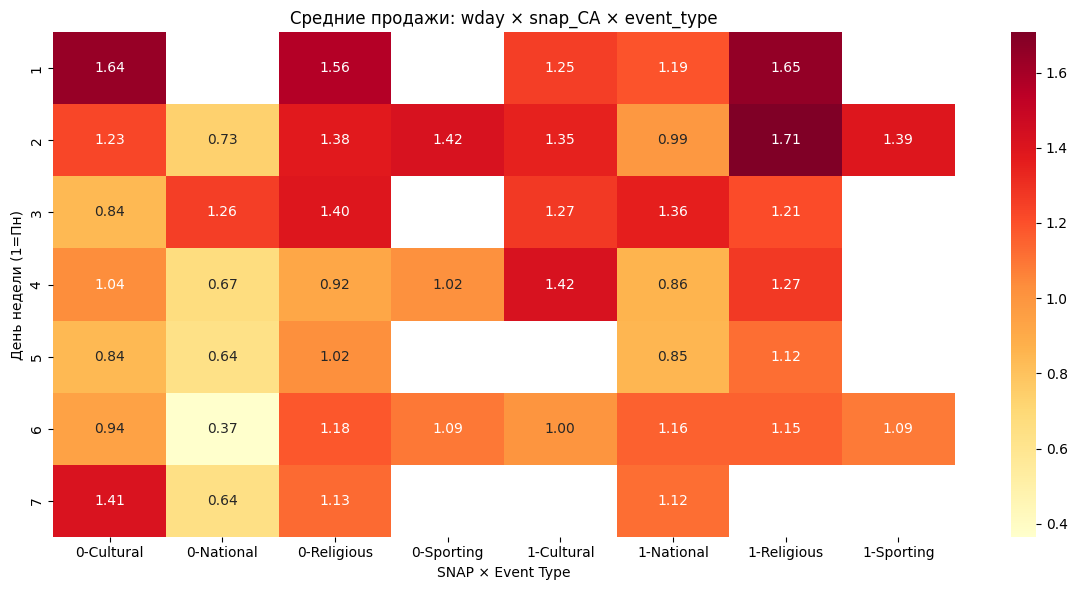

In [57]:
heatmap_data = df_final.groupby(['snap_CA', 'event_type_1', 'wday'])['sales'].mean().reset_index()
pivot = heatmap_data.pivot_table(values='sales', index='wday', columns=['snap_CA', 'event_type_1'], aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Средние продажи: wday × snap_CA × event_type')
plt.xlabel('SNAP × Event Type')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()